In [ ]:
"""
04_velorama_grn.py
Build the curated AnnData and infer the definitive Granger-causal GRN.

Reads : prepared .h5ad (all protein-coding + Harmony) from step 00
        clustassess_chosen_hvg.txt from step 01
Writes: liver_endstage.h5
ad (curated: reg/target/background, DPT, X_pca, iroot)
        *_grn_scores.csv, *_lag_scores.csv, *_interactions_ranked.csv, null scores

Every gene set / path / training hyperparameter comes from gribben_config so this
stage trains in the SAME stable regime the seed-stability stage (05) validates.
Run Jupyter/python from the folder holding gribben_config.py.
"""
import os
from gribben_config import *          # paths, gene sets, LAG, N_BACKGROUND_GENES, STABLE_TRAIN_CONFIG, N_CPUS ...
for _v in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[_v] = str(N_CPUS)

import glob, time
import numpy as np, pandas as pd, scipy.sparse as sp
import scanpy as sc, anndata as ad, torch
from joblib import Parallel, delayed
from velorama import train_model
from velorama.utils import construct_dag, calculate_diffusion_lags
sc.settings.n_jobs = N_CPUS

OUTPUT_DIR   = VELO_DIR
DATASET_NAME = DATASET_CURATED        # "liver_endstage"
N_TOP_HVGS   = n_top_hvgs()           # ClustAssess decision (step 01)

# ============================================================================

c:\Users\Floarea\miniconda3\envs\velorama\lib\site-packages\ray\_private\parameter.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 100


In [3]:
# PART A — build the curated AnnData
# ============================================================================

In [4]:
# === STEP 1: load prepared data and guarantee X is log-normalised ===
adata = sc.read_h5ad(PREPARED_H5AD)
Xs = adata.X[:500, :500]
Xs = Xs.toarray() if sp.issparse(Xs) else np.asarray(Xs)
if np.allclose(Xs, Xs.astype(int)) and Xs.max() > 20:            # raw counts -> normalise
    adata.layers.setdefault("counts", adata.X.copy())
    sc.pp.normalize_total(adata, target_sum=1e4); sc.pp.log1p(adata)
elif sp.issparse(adata.X):                                       # already norm -> just clean
    adata.X.data = np.nan_to_num(adata.X.data)
print(f"Loaded {adata.n_obs} cells x {adata.n_vars} genes")

Loaded 20968 cells x 17253 genes


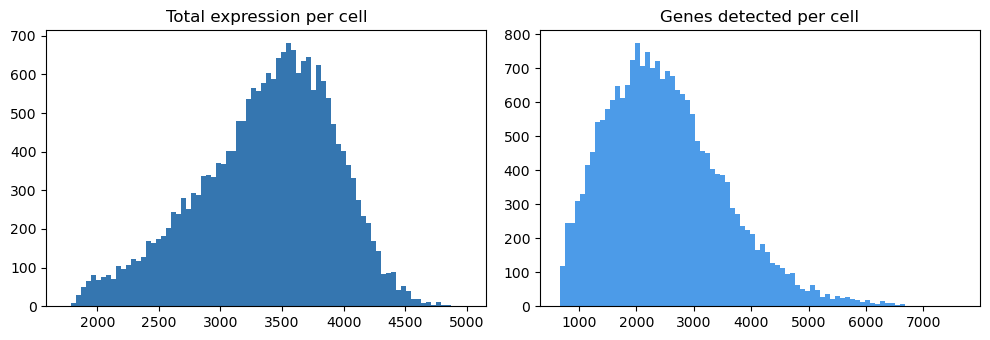

: 

In [ ]:
# --- VIZ: library size / QC after load+normalise check ---
lib_size = np.asarray(adata.X.sum(axis=1)).flatten()
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(lib_size, bins=80, color='#3576b0'); ax[0].set_title('Total expression per cell')
ax[1].hist(np.asarray((adata.X > 0).sum(axis=1)).flatten(), bins=80, color='#4C9BE8')
ax[1].set_title('Genes detected per cell'); plt.tight_layout(); plt.show()


In [ ]:
# === STEP 2: remove doublets + score cell cycle ===
# Cell-cycle scores are kept so we can later confirm pseudotime is a lineage axis,
# not a proliferation artefact (STEP 9).
try:
    sc.pp.scrublet(adata)                                        # adds predicted_doublet
    adata = adata[~adata.obs.get("predicted_doublet", False)].copy()
except Exception as e:
    print("scrublet skipped:", e)
_cc = "MCM5 PCNA TYMS FEN1 MCM2 CDK1 UBE2C BIRC5 TOP2A CKS2".split()  # abbreviated S/G2M markers
sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=[g for g in _cc[:5] if g in adata.var_names],
    g2m_genes=[g for g in _cc[5:] if g in adata.var_names])

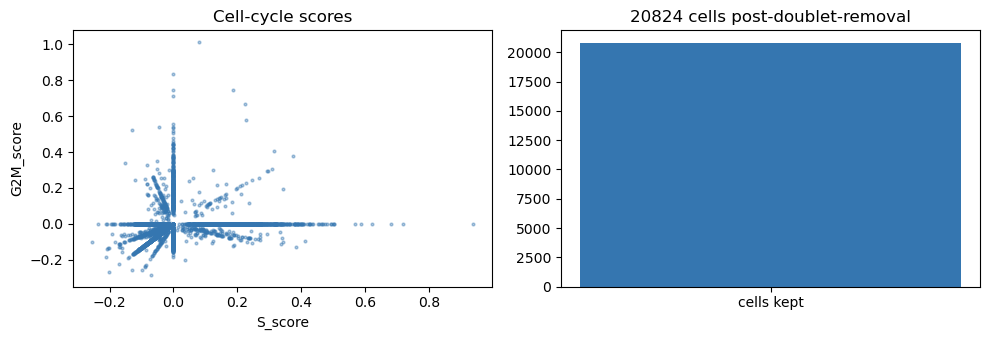

In [ ]:
# --- VIZ: doublets removed + cell-cycle score distribution ---
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
if {'S_score','G2M_score'} <= set(adata.obs):
    ax[0].scatter(adata.obs.S_score, adata.obs.G2M_score, s=4, alpha=.4, c='#3576b0')
    ax[0].set_xlabel('S_score'); ax[0].set_ylabel('G2M_score'); ax[0].set_title('Cell-cycle scores')
ax[1].bar(['cells kept'], [adata.n_obs], color='#3576b0'); ax[1].set_title(f'{adata.n_obs} cells post-doublet-removal')
plt.tight_layout(); plt.show()


In [ ]:
# === STEP 3: highly-variable genes (seurat_v3 on counts, N from ClustAssess) ===
sc.pp.highly_variable_genes(adata, n_top_genes=N_TOP_HVGS, flavor="seurat_v3",
                            layer="counts", subset=False)

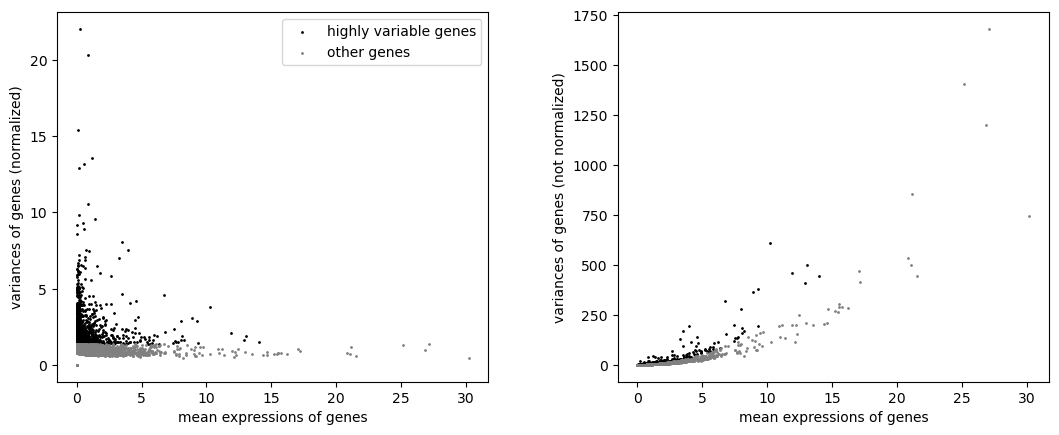

In [ ]:
# --- VIZ: mean-variance relationship, HVGs highlighted ---
sc.pl.highly_variable_genes(adata)


In [ ]:
# === STEP 4: regulators (TFs) vs targets (HVGs) ===
tf_list = set(open(TF_LIST_PATH).read().split()) if os.path.exists(TF_LIST_PATH) else set()
adata.var["is_reg"]    = adata.var_names.isin(tf_list) | adata.var_names.isin(LINEAGE_TFS)
adata.var["is_target"] = adata.var["highly_variable"] & ~adata.var["is_reg"]

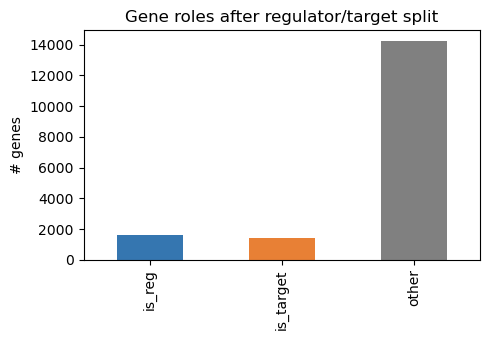

In [ ]:
# --- VIZ: regulator / target / other gene counts ---
counts = adata.var[['is_reg','is_target']].sum()
counts['other'] = adata.n_vars - counts.sum()
counts.plot(kind='bar', color=['#3576b0','#e88035','grey'], figsize=(5,3.5))
plt.title('Gene roles after regulator/target split'); plt.ylabel('# genes'); plt.tight_layout(); plt.show()


In [ ]:
# === STEP 5: refine targets to hep<->chol DE genes ===
# Targets should be genes that actually change across the transition, so intersect
# HVG targets with Wilcoxon DEGs between the two endpoints.
traj = ["Hepatocytes", "Cholangiocytes"]
ad_t = adata[adata.obs["cell.annotation"].isin(traj)].copy()
if sp.issparse(ad_t.X): ad_t.X.data = np.clip(ad_t.X.data, 0, None)
sc.tl.rank_genes_groups(ad_t, "cell.annotation", groups=traj, reference="rest",
                        method="wilcoxon", n_genes=300, use_raw=False)
deg = set()
for grp in traj:
    d = sc.get.rank_genes_groups_df(ad_t, group=grp)
    sig = d[(d.logfoldchanges.abs() >= 1.0) & (d.pvals_adj <= 0.05)]
    if len(sig) == 0:                                            # fallback for compressed logFC scales
        sig = d[(d.scores > 0) & (d.pvals_adj <= 0.05)]
    deg |= set(sig.names)
targets = (deg & set(adata.var_names[adata.var.highly_variable])) - set(adata.var_names[adata.var.is_reg])
if len(targets) >= 100:
    adata.var["is_target"] = adata.var_names.isin(targets)
print(f"Regulators: {adata.var.is_reg.sum()} | targets: {adata.var.is_target.sum()}")

Regulators: 1643 | targets: 247


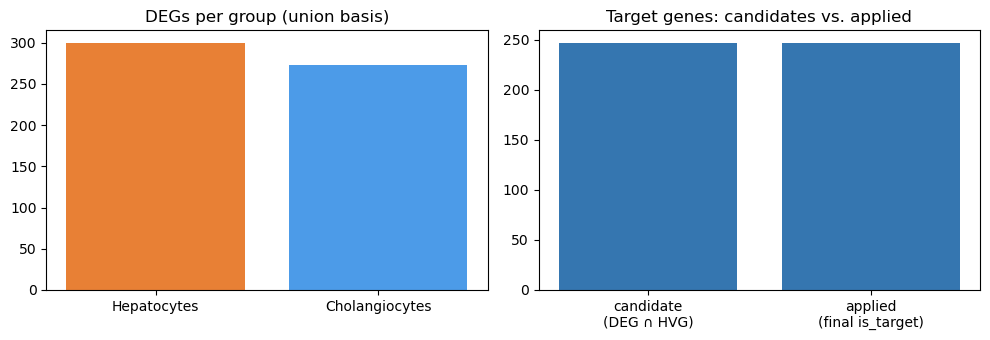

In [ ]:
# --- VIZ: DEG counts per group + candidate-vs-applied target counts ---
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].bar(traj, [len(deg & set(sc.get.rank_genes_groups_df(ad_t, group=g).names)) for g in traj],
          color=['#e88035','#4C9BE8'])
ax[0].set_title('DEGs per group (union basis)')
ax[1].bar(['candidate\n(DEG ∩ HVG)', 'applied\n(final is_target)'],
          [len(targets), int(adata.var.is_target.sum())], color='#3576b0')
ax[1].set_title('Target genes: candidates vs. applied')
plt.tight_layout(); plt.show()


In [ ]:
# === STEP 6: subset to regulators + targets + a background context set ===
# Background genes condition the Granger fits without being reported as edges.
important = adata.var.is_reg | adata.var.is_target
bg = adata.var_names[~important]
rng = np.random.default_rng(42)
bg_keep = bg.to_numpy() if (N_BACKGROUND_GENES is None or len(bg) <= N_BACKGROUND_GENES) \
          else rng.choice(bg.to_numpy(), N_BACKGROUND_GENES, replace=False)
adata = adata[:, pd.Index(adata.var_names[important]).union(pd.Index(bg_keep))].copy()

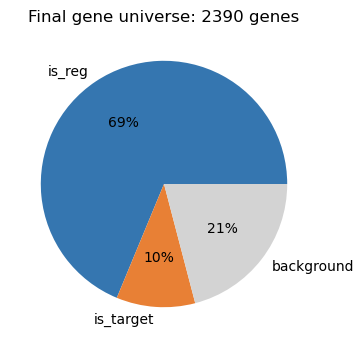

In [ ]:
# --- VIZ: final gene composition after background subsetting ---
comp = adata.var[['is_reg','is_target']].sum()
comp['background'] = adata.n_vars - comp.sum()
plt.figure(figsize=(4,4)); plt.pie(comp, labels=comp.index, autopct='%1.0f%%',
                                   colors=['#3576b0','#e88035','lightgrey'])
plt.title(f'Final gene universe: {adata.n_vars} genes'); plt.show()


In [ ]:
# === STEP 7: trajectory scaffold — PCA/neighbours/diffmap + DPT rooted at hepatocytes ===
# Ground truth: hepatocytes at pseudotime 0, cholangiocytes at 1.
sc.pp.pca(adata, n_comps=20, mask_var="highly_variable", svd_solver="auto")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)
sc.tl.diffmap(adata, n_comps=10)
hep = np.where((adata.obs["cell.annotation"] == "Hepatocytes").values)[0]
adata.uns["iroot"] = int(hep[np.argmin(adata.obsm["X_diffmap"][hep, 0])])
sc.tl.dpt(adata, n_dcs=10)

C:\Users\Floarea\AppData\Local\Temp\ipykernel_13316\261391880.py:3: UserWarning: Ignoring svd_solver='auto' and using arpack, sklearn.decomposition._pca.PCA (with sparse input) only supports dict_keys(['arpack', 'covariance_eigh']).
  sc.pp.pca(adata, n_comps=20, mask_var="highly_variable", svd_solver="auto")


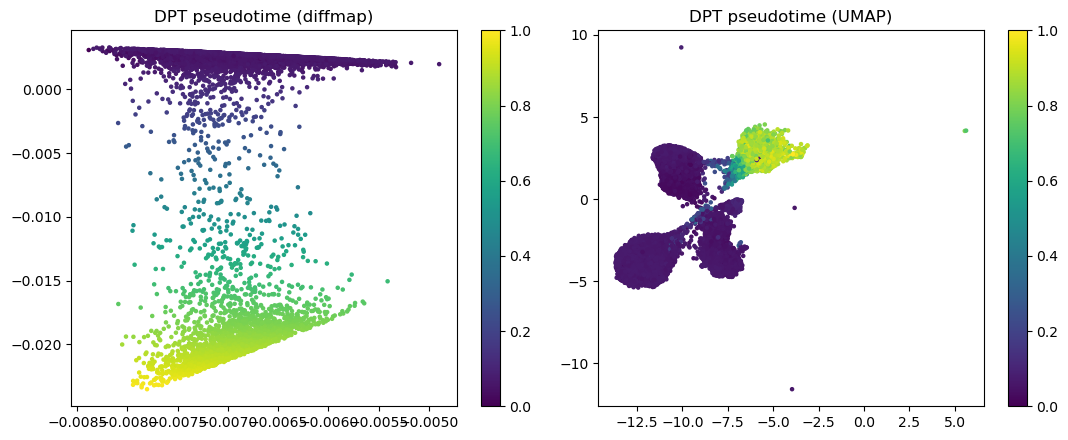

In [ ]:
# --- VIZ: DPT pseudotime on UMAP/diffmap (trajectory sanity check) ---
if 'X_umap' not in adata.obsm: sc.tl.umap(adata)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sc1 = ax[0].scatter(*adata.obsm['X_diffmap'][:, :2].T, c=adata.obs.dpt_pseudotime, cmap='viridis', s=5)
ax[0].set_title('DPT pseudotime (diffmap)'); plt.colorbar(sc1, ax=ax[0])
sc2 = ax[1].scatter(*adata.obsm['X_umap'].T, c=adata.obs.dpt_pseudotime, cmap='viridis', s=5)
ax[1].set_title('DPT pseudotime (UMAP)'); plt.colorbar(sc2, ax=ax[1])
plt.tight_layout(); plt.show()


In [ ]:
# === STEP 8: sanity — pseudotime should not be driven by the cell cycle ===
if {"S_score", "G2M_score"} <= set(adata.obs):
    for k in ["S_score", "G2M_score"]:
        print(f"corr(dpt, {k}) = {np.corrcoef(adata.obs.dpt_pseudotime, adata.obs[k])[0,1]:.3f} (want ~0)")

corr(dpt, S_score) = -0.050 (want ~0)
corr(dpt, G2M_score) = -0.094 (want ~0)


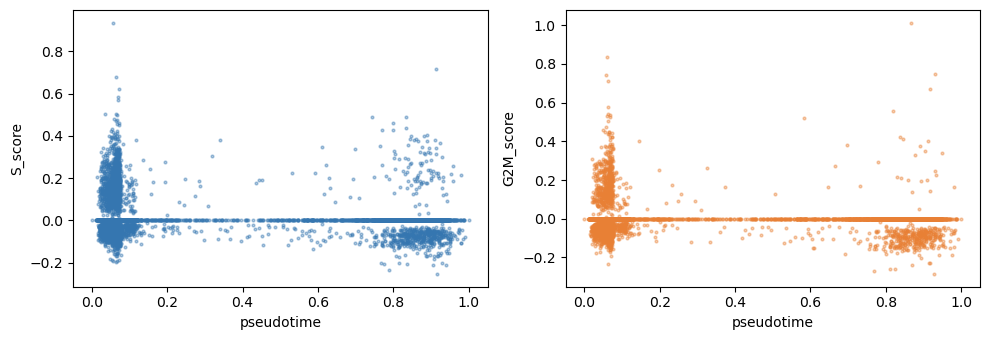

In [ ]:
# --- VIZ: pseudotime vs cell-cycle scatter (want ~flat / uncorrelated) ---
if {'S_score','G2M_score'} <= set(adata.obs):
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].scatter(adata.obs.dpt_pseudotime, adata.obs.S_score, s=4, alpha=.4, c='#3576b0')
    ax[0].set_xlabel('pseudotime'); ax[0].set_ylabel('S_score')
    ax[1].scatter(adata.obs.dpt_pseudotime, adata.obs.G2M_score, s=4, alpha=.4, c='#e88035')
    ax[1].set_xlabel('pseudotime'); ax[1].set_ylabel('G2M_score')
    plt.tight_layout(); plt.show()


In [ ]:
# === STEP 9: persist curated AnnData (gene roles in .uns for exact recovery) ===
adata.uns["velorama_reg_names"]    = list(adata.var_names[adata.var.is_reg])
adata.uns["velorama_target_names"] = list(adata.var_names[adata.var.is_target])
adata.X = adata.X.astype(np.float32)
adata.write_h5ad(CURATED_H5AD)
print("Wrote curated ->", CURATED_H5AD)

# ============================================================================

Wrote curated -> C:\Users\Floarea\Desktop\analyses\scRNA-Gribben\99_results\velorama\liver_endstage.h5ad


In [ ]:
# PART B — definitive causal GRN (stable regime from gribben_config)
# ============================================================================
adata_sub  = adata                                    # continue in-memory (== CURATED_H5AD)
reg_names  = list(adata_sub.var_names[adata_sub.var.is_reg])
target_idx = np.where(adata_sub.var.is_target.values)[0]

In [ ]:
# === STEP 10: scale + build the pseudotime DAG + diffusion lags (Velorama inputs) ===
sc.pp.scale(adata_sub)
X_np = np.ascontiguousarray(np.nan_to_num(
    adata_sub.X.toarray() if sp.issparse(adata_sub.X) else np.asarray(adata_sub.X)).astype(np.float32))
A  = construct_dag(adata_sub, dynamics="pseudotime", ptloc=None, proba=False)
AX = calculate_diffusion_lags(A, torch.tensor(X_np), LAG)
AX_np = AX.numpy() if isinstance(AX, torch.Tensor) else np.asarray(AX, dtype=np.float32)

c:\Users\Floarea\miniconda3\envs\velorama\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
# === STEP 11: train one Granger model per target (parallel), then load results ===
TRAIN = {**STABLE_TRAIN_CONFIG, "seed": 43, "results_dir": OUTPUT_DIR, "dir_name": DATASET_NAME}
os.makedirs(os.path.join(OUTPUT_DIR, DATASET_NAME), exist_ok=True)

def _train(t, gene, X, AXn, cfg):
    import torch; from velorama import train_model
    torch.set_num_threads(1)
    AXt = torch.tensor(AXn, dtype=torch.float32)
    train_model({"AX": AXt, "AY": AXt, "Y": torch.tensor(X[:, [t]], dtype=torch.float32),
                 "name": gene, **cfg})

def _load(pt_dir, gene, lag):                          # glob by gene: robust to seed/lam tokens
    hit = [p for p in glob.glob(os.path.join(pt_dir, f"{gene}.*lag{lag}.pseudotime.pt"))
           if not p.endswith(".ignore_lag.pt")]
    if not hit: return None
    return torch.load(hit[0], map_location="cpu").detach().numpy()[0]   # (n_predictors, n_lags)

Parallel(n_jobs=max(1, min(3, N_CPUS)), backend="loky", verbose=5)(
    delayed(_train)(int(t), str(adata_sub.var_names[t]), X_np, AX_np, TRAIN) for t in target_idx)

pt_dir = os.path.join(OUTPUT_DIR, DATASET_NAME)
gc = {t: _load(pt_dir, adata_sub.var_names[t], LAG) for t in target_idx}
gc = {t: v for t, v in gc.items() if v is not None}
print(f"Loaded {len(gc)}/{len(target_idx)} target models")

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.


In [ ]:
# === STEP 12: assemble regulators x targets GRN (edge score = max over lags) ===
genes = adata_sub.var_names
grn_full = pd.DataFrame(0.0, index=genes, columns=genes)
lag_full = pd.DataFrame(0.0, index=genes, columns=genes)
for t, GC in gc.items():
    n = min(GC.shape[0], len(genes))
    grn_full.iloc[:n, t] = GC[:n].max(axis=1)
    lag_full.iloc[:n, t] = GC[:n].argmax(axis=1)          # which lag carried the edge
target_names = list(adata_sub.var_names[adata_sub.var.is_target])
grn_df = grn_full.loc[reg_names, target_names]
lag_df = lag_full.loc[reg_names, target_names]
grn_df.to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_grn_scores.csv"))
lag_df.to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_lag_scores.csv"))

In [ ]:
# --- VIZ: GRN heatmap (top regulators x top targets by influence) + top-edge bar ---
import seaborn as sns
top_reg = grn_df.sum(axis=1).nlargest(20).index
top_tgt = grn_df.loc[top_reg].sum(axis=0).nlargest(30).index
plt.figure(figsize=(10, 6))
sns.heatmap(grn_df.loc[top_reg, top_tgt], cmap='viridis', cbar_kws={'label':'GRN score'})
plt.title('Top regulators x top targets'); plt.tight_layout(); plt.show()

_edges = grn_df.stack().reset_index(); _edges.columns = ['TF','target','grn_score']
top_edges = _edges[_edges.TF != _edges.target].sort_values('grn_score', ascending=False).head(15)
plt.figure(figsize=(6, 4))
plt.barh([f'{r.TF}->{r.target}' for _, r in top_edges.iloc[::-1].iterrows()], top_edges.iloc[::-1].grn_score, color='#3576b0')
plt.title('Top 15 TF-target edges'); plt.tight_layout(); plt.show()


In [ ]:
# === STEP 13: permutation null -> significance threshold (SAME regime, pseudotime shuffled) ===
# Only the pseudotime is permuted, so the null must otherwise match the real GRN's
# config; otherwise the threshold is not comparable.
NULL_SEED, N_NULL_GENES, N_NULL_CELLS = 99, 30, 3000
rng_n = np.random.default_rng(NULL_SEED)
an = ad.read_h5ad(CURATED_H5AD)
an.obs["dpt_pseudotime"] = rng_n.permutation(an.obs["dpt_pseudotime"].values)
sel = np.sort(rng_n.choice(an.n_obs, min(N_NULL_CELLS, an.n_obs), replace=False))  # memory cap
an = an[sel].copy(); sc.pp.scale(an)
Xn = np.ascontiguousarray(np.nan_to_num(
    an.X.toarray() if sp.issparse(an.X) else np.asarray(an.X)).astype(np.float32))
An  = construct_dag(an, dynamics="pseudotime", ptloc=None, proba=False)
AXn = calculate_diffusion_lags(An, torch.tensor(Xn), LAG)
AXn = AXn.numpy() if isinstance(AXn, torch.Tensor) else np.asarray(AXn, dtype=np.float32)
NCFG = {**STABLE_TRAIN_CONFIG, "seed": NULL_SEED, "results_dir": OUTPUT_DIR,
        "dir_name": f"{DATASET_NAME}_null"}
null_t = rng_n.choice(target_idx, min(N_NULL_GENES, len(target_idx)), replace=False)
for t in null_t:
    _train(int(t), f"null_{an.var_names[t]}", Xn, AXn, NCFG)
null_pt = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_null")
null_scores = np.concatenate([
    (v[:, :].max(axis=1) if v.ndim == 2 else v)
    for t in null_t if (v := _load(null_pt, f"null_{an.var_names[t]}", LAG)) is not None])
P99 = float(np.percentile(null_scores, 99))
print(f"Null p99 threshold = {P99:.4f}")

In [ ]:
# --- VIZ: null vs real GRN-score distribution (where the p99 threshold falls) ---
plt.figure(figsize=(7,4))
plt.hist(null_scores, bins=80, alpha=.6, density=True, label='null (shuffled pseudotime)', color='grey')
plt.hist(grn_df.values.flatten(), bins=80, alpha=.6, density=True, label='real GRN', color='#3576b0')
plt.axvline(P99, color='crimson', linestyle='--', label=f'p99 = {P99:.3f}')
plt.legend(); plt.title('Real GRN scores vs. permutation null'); plt.tight_layout(); plt.show()


In [ ]:
# === STEP 14: ranked, significance-tagged edge list ===
res = grn_df.stack().reset_index()
res.columns = ["TF", "target", "grn_score"]
res = res[res.TF != res.target].merge(
    lag_df.stack().reset_index().set_axis(["TF", "target", "lag_score"], axis=1),
    on=["TF", "target"], how="left")
res["significant_p99"] = res.grn_score > P99
res.sort_values("grn_score", ascending=False).to_csv(
    os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_interactions_ranked.csv"), index=False)
print(f"Edges: {len(res):,} | significant (p99): {int(res.significant_p99.sum()):,}")

In [ ]:
# --- VIZ: significance summary + top significant edges table ---
fig, ax = plt.subplots(figsize=(4,3.5))
ax.bar(['total','significant p99'], [len(res), int(res.significant_p99.sum())], color=['grey','#3576b0'])
ax.set_title('Edges passing the null threshold'); plt.tight_layout(); plt.show()
res.sort_values('grn_score', ascending=False).head(10)


In [ ]:
# === STEP 15 (optional): functional enrichment of top target genes ===
# from gprofiler import GProfiler   # g:Profiler on top-influence targets, background = expressed genes

## NEXT STEPS / GAPS
## - STEP 2 uses ABBREVIATED cell-cycle marker lists for brevity; swap in the full
##   Tirosh et al. S/G2M gene lists for a proper cell-cycle score before quoting it.
## - CHOSEN_LAM defaults to 0.05; confirm it with step 05's lam sweep, then re-run
##   PART B (the .pt filenames and null threshold depend on lam).
## - The null subsamples 3,000 cells for memory while the real GRN uses all cells;
##   match them if RAM allows for a stricter null.
## - PART B keeps the 500-gene background context set; drop it (N_BACKGROUND_GENES=0)
##   if you want the headline GRN on exactly the curated reg+target universe (step 05).
## - A single permutation gives a threshold, not a calibrated p-value; run several
##   permutations for a proper FPR estimate.